## 1. Environment Setup & Dependency Initialization
In this section, we initialize the required environment by importing core data science libraries, deep learning frameworks (`PyTorch`), and system management utilities. Garbage collection and system path configurations are established to manage heavy model weights during memory-intensive processing.

In [1]:
import os
import sys
import gc
import pandas as pd
import numpy as np
import torch

# Optimize PyTorch memory allocation before loading large language models
torch.cuda.empty_cache()
gc.collect()

40

## 2. Ingestion of Raw Financial Analyst Ratings Dataset
We ingest the raw text dataset containing financial news headlines along with their historical timestamps. To minimize memory footprint, we strictly filter and load only the required features (`title` and `date`).

In [2]:
# Load only relevant columns from the processed analyst ratings dataset
raw_data_path = "../data/raw/analyst_ratings_processed.csv"
headlines_df = pd.read_csv(raw_data_path, usecols=["title", "date"])

# Preview structural layout of raw text data
headlines_df.head()

,title,date
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00-04:00
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00-04:00
2,71 Biggest Movers From Friday,2020-05-26 04:30:00-04:00
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00-04:00
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00-04:00


## 3. Data Cleansing, Normalization, & Temporal Gap Analysis
This module performs rigorous preprocessing on timestamps. It drops null entries, sanitizes date strings using standardized Regular Expressions (`YYYY-MM-DD`), and parses them into `datetime64[ns]` formats. Additionally, it maps the temporal coverage against a complete business calendar to identify trading day data gaps (weekdays vs. weekends).

In [3]:
# Drop rows with missing text or temporal data
headlines_df = headlines_df.dropna()
headlines_df['text'] = headlines_df['title'].astype(str)

# Extract ISO date format (YYYY-MM-DD) from the raw timestamp string
headlines_df['date_clean'] = headlines_df['date'].apply(lambda x: str(x).split(" ")[0])

# Enforce strict regex validation for dates
regex_pattern = r'^\d{4}-\d{2}-\d{2}'
is_valid_date = headlines_df['date_clean'].astype(str).str.contains(regex_pattern, regex=True)

valid_df = headlines_df[is_valid_date].copy()
invalid_df = headlines_df[~is_valid_date].copy()

# Log dataset filtering summary statistics
total_records = len(headlines_df)
print(f"Total processed records: {total_records}")
print(f"Valid records parsed: {len(valid_df)} ({len(valid_df)/total_records:.1%})")
print(f"Invalid records removed: {len(invalid_df)} ({len(invalid_df)/total_records:.1%})")

# Finalize datetime casting and sort chronologically
headlines_df = valid_df.copy()
headlines_df['date'] = pd.to_datetime(headlines_df['date_clean'], format='%Y-%m-%d')
headlines_df = headlines_df.drop(columns=['date_clean', 'title'])
headlines_df = headlines_df.sort_values('date').reset_index(drop=True)

print(f"Cleaned dataset final record count: {len(headlines_df)}")
print(f"Column 'date' cast to type: {headlines_df['date'].dtype}")

# Generate a continuous business/calendar time-range matrix
full_date_range = pd.date_range(start=headlines_df['date'].min(), 
                               end=headlines_df['date'].max(), 
                               freq='D')

# Map and isolate missing timeline segments (gaps)
missing_dates = full_date_range.difference(headlines_df['date'].unique())
dates_with_news = headlines_df['date'].unique()

print(f"Total continuous calendar days in period: {len(full_date_range)}")
print(f"Active calendar days with news coverage: {len(dates_with_news)}")
print(f"Missing calendar gaps (days with zero news): {len(missing_dates)}")
print(f"Total raw news entries inside the corpus: {len(headlines_df)}")

# Audit calendar gaps to categorize weekend anomalies vs. business day lapses
missing_dates_df = pd.DataFrame(missing_dates, columns=['date'])
missing_dates_df['day_of_week'] = missing_dates_df['date'].dt.dayofweek
missing_dates_df['day_name'] = missing_dates_df['date'].dt.day_name()

weekend_gaps = missing_dates_df[missing_dates_df['day_of_week'] >= 5]
weekday_gaps = len(missing_dates_df) - len(weekend_gaps)

print(f"Total missing days analyzed: {len(missing_dates_df)}")
print(f"Missing days classified as weekends: {len(weekend_gaps)}")
print(f"Missing days classified as business days: {weekday_gaps}")

# Display sample of initial unmapped business days
print("\nFirst 10 missing business days with zero news coverage:")
print(missing_dates_df[missing_dates_df['day_of_week'] < 5].head(10))

Total processed records: 1399180
Valid records parsed: 1397891 (99.9%)
Invalid records removed: 1289 (0.1%)
Cleaned dataset final record count: 1397891
Column 'date' cast to type: datetime64[us]
Total continuous calendar days in period: 4136
Active calendar days with news coverage: 3957
Missing calendar gaps (days with zero news): 179
Total raw news entries inside the corpus: 1397891
Total missing days analyzed: 179
Missing days classified as weekends: 79
Missing days classified as business days: 100

First 10 missing business days with zero news coverage:
         date  day_of_week   day_name
1  2009-02-16            0     Monday
2  2009-02-17            1    Tuesday
3  2009-02-18            2  Wednesday
4  2009-02-19            3   Thursday
5  2009-02-20            4     Friday
8  2009-02-23            0     Monday
9  2009-02-24            1    Tuesday
10 2009-02-25            2  Wednesday
11 2009-02-26            3   Thursday
12 2009-02-27            4     Friday


## 4. Deep Learning Pipeline: Loading FinBERT and rsLoRA Adapters
We load the pre-trained domain-specific **FinBERT** base model (`ProsusAI/finbert`) along with custom fine-tuned **rsLoRA (Rank-Stabilized Low-Rank Adaptation)** weights. This configuration allows for specialized financial sentiment classification while maintaining a lightweight parameter footprint.

In [4]:
# Append root directory to sys.path to enable specialized local module imports
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.sentiment_pipeline import load_rslora_model, analyze_sentiment

MODEL_PATH = "../models/finbert_rslora_finetuned"
BASE_MODEL_NAME = "ProsusAI/finbert"

# Purge memory cache before mapping neural network layers to VRAM
torch.cuda.empty_cache()
gc.collect()

print("Initializing FinBERT architecture and loading rsLoRA parameters...")
model, tokenizer, device = load_rslora_model(BASE_MODEL_NAME, MODEL_PATH)

if model is None:
    raise RuntimeError("Model loading failure. Verify directory tree pathing.")

/home/pruebas/miniconda3/envs/dream_tfm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing FinBERT architecture and loading rsLoRA parameters...

[INFO] Loading FinBERT base model and rsLoRA weights from: ../models/finbert_rslora_finetuned


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 54538.43it/s]


[INFO] Model loaded successfully on cuda.


## 5. High-Throughput Batched Sentiment Inference
We execute highly optimized batched sentiment inference over the cleaned textual news database. We use a maximized batch size ($8192$) to accelerate GPU tensor operations.

In [5]:
# Set high-throughput batch allocation based on GPU memory thresholds
batch_size = 8192 

print(f"Launching sentiment inference across {len(headlines_df)} textual records...")
df_result = analyze_sentiment(
    headlines_df, 
    model, 
    tokenizer, 
    device, 
    temperature=1.0, 
    batch_size=batch_size
)

# VRAM memory collection post-inference
torch.cuda.empty_cache()
gc.collect()

print("Sentiment inference phase completed successfully.")
print(df_result[['date', 'text', 'sentiment_score']].head(64))

Launching sentiment inference across 1397891 textual records...

[INFO] Running sentiment inference (temperature=1.0)...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Sentiment inference phase completed successfully.
         date                                               text  \
0  2009-02-14                       How Treasuries and ETFs Work   
1  2009-04-27      Update on the Luxury Sector: 2nd Quarter 2009   
2  2009-04-27      Update on the Luxury Sector: 2nd Quarter 2009   
3  2009-04-29                             Going Against the Herd   
4  2009-05-22  Charles Sizemore Radio Interview Saturday Morning   
..        ...                                                ...   
59 2009-07-08                                                SPY   
60 2009-07-10                                                SUN   
61 2009-07-14  Skystar Bio-Pharmaceutical Announces Expansion...   
62 2009-07-14  Skystar Bio-Pharmaceutical Announces Expansion...   
63 2009-07-14  Skystar Bio-Pharmaceutical Announces Expansion...   

    sentiment_score  
0         -0.006576  
1          0.008508  
2          0.008508  
3         -0.137727  
4          0.039920  
.

## 6. Deduplication and Initial Cleaned Corpus Export
Financial news aggregators frequently republish identical boilerplate text strings across a single trading day (e.g., automated market updates). In this step, we profile duplicate items and clean the dataset by keeping only the first chronological occurrence.

In [6]:
# Audit frequency of duplicate text strings per day
duplicate_distribution = df_result.value_counts(subset=['text', 'date'])
print("Top 10 recurring boilerplate/duplicated headlines found:")
print(duplicate_distribution.head(10))

# Deduplicate by maintaining the first occurrence of unique (text, date) pairs
df_result_cleaned = df_result.drop_duplicates(subset=['text', 'date'], keep='first')
print(f"Original record size before deduplication: {len(df_result)}")
print(f"Cleaned unique text database size: {len(df_result_cleaned)}")

# Save the resulting deduplicated text and sentiment probabilities
df_result_cleaned.to_csv("../data/analyst_ratings_cleaned.csv", index=False)

Top 10 recurring boilerplate/duplicated headlines found:
text                                                      date      
Stocks That Hit 52-Week Lows On Thursday                  2020-03-12    1703
                                                          2020-03-19     753
Stocks That Hit 52-Week Lows On Friday                    2020-02-28     713
                                                          2020-03-06     623
Stocks That Hit 52-Week Lows On Thursday                  2020-02-27     561
Stocks That Hit 52-Week Lows On Monday                    2020-03-23     490
Stocks That Hit 52-Week Lows On Wednesday                 2020-03-11     417
Stocks Which Set New 52-Week Low Yesterday, October 23rd  2018-10-24     368
Stocks Which Set New 52-Week Low Yesterday, October 22nd  2018-10-23     355
Stocks Which Set New 52-Week Low Friday, October 26th     2018-10-29     354
Name: count, dtype: int64
Original record size before deduplication: 1397891
Cleaned unique text databas

## 7. Mathematical Consolidation: Daily Intensity-Weighted Macro Sentiment Calculation
Instead of using a simple arithmetic mean, we compute an **Intensity-Weighted Daily Sentiment Score**. We define the weight of an entity as its non-neutrality ($1.0 - \text{probability of neutral prediction}$). This ensures that standard market noise does not dilute high-conviction market signals.

The daily macroeconomic index score is defined as:

$$\text{Daily Sentiment}_t = \frac{\sum (\text{Sentiment Score}_i \times \text{Intensity Weight}_i)}{\sum \text{Intensity Weight}_i}$$

In [7]:
# Calculate non-neutrality intensity weight matrix
df_result_cleaned['intensity_weight'] = 1.0 - df_result_cleaned['prob_neutral']

def compute_weighted_daily_sentiment(group):
    """Calculates intensity-weighted average sentiment score for a given day."""
    scores = group['sentiment_score']
    weights = group['intensity_weight']
    
    sum_weights = weights.sum()
    
    # Mathematical edge-case prevention (division by zero on pure neutral days)
    if sum_weights == 0:
        return 0.0
        
    return (scores * weights).sum() / sum_weights

print("Computing daily intensity-weighted aggregate sentiment metrics...")
df_daily = df_result_cleaned.groupby('date').apply(compute_weighted_daily_sentiment).reset_index(name='daily_sentiment')
df_daily = df_daily.sort_values('date').reset_index(drop=True)

print("Sample matrix of daily macroeconomic consolidated sentiment:")
print(df_daily.head(10))

# Save daily weighted sentiment to file
df_daily.to_csv("../data/analyst_ratings_weighted_sentiment.csv", index=False)

Computing daily intensity-weighted aggregate sentiment metrics...
Sample matrix of daily macroeconomic consolidated sentiment:
        date  daily_sentiment
0 2009-02-14        -0.006576
1 2009-04-27         0.008508
2 2009-04-29        -0.137727
3 2009-05-22         0.039920
4 2009-05-27         0.774569
5 2009-05-29        -0.001260
6 2009-05-30         0.718110
7 2009-06-01         0.444905
8 2009-06-02         0.055308
9 2009-06-05         0.081887


## 8. Integration of Quantitative Market and Textual Sentiment Datasets
We merge the daily macroeconomic sentiment index with historical quantitative multi-asset market data (prices, volumes, and returns). The merge uses a left join based on the market calendar to match every asset's trading day with the prevailing sentiment landscape.

In [8]:
# Load market and sentiment matrices
df_sentiment = pd.read_csv("../data/analyst_ratings_weighted_sentiment.csv")
df_market = pd.read_csv("../data/quantitative_market_dataset.csv")

# Format datatypes and join datasets
df_market['Date'] = pd.to_datetime(df_market['Date'])
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# Isolate valid temporal limits of empirical news data
min_sentiment_date = df_sentiment['date'].min()
max_sentiment_date = df_sentiment['date'].max()

# Merge left on market calendar to maintain trading day continuity
df_merged = pd.merge(df_market, df_sentiment, left_on='Date', right_on='date', how='left')
df_merged = df_merged.drop(columns=['date'])
df_merged = df_merged.sort_values(by=['Date', 'ticker']).reset_index(drop=True)

# Restrict combined dataframe to the operational news window
valid_window_mask = (df_merged['Date'] >= min_sentiment_date) & (df_merged['Date'] <= max_sentiment_date)
df_merged = df_merged[valid_window_mask].copy()

## 9. Temporal Imputation, Edge-Case Stabilization, and Business Calendar Integrity Audit
Market timelines often mismatch with news streams due to holidays and weekends. To resolve this without introducing *data leakage*, we apply a **Forward-Fill (ffill)** strategy grouped by asset ticker. This propagates the latest known sentiment forward until a new information shock arrives. 

We also verify that any unmapped entries (set to `0.0`) are isolated at the beginning of the timeline, before the news corpus began. Finally, we run a data integrity test to ensure no trading days were dropped.

In [9]:
# Pre-imputation data profiling
raw_sentiment_series = df_merged.groupby('Date')['daily_sentiment'].first()
total_market_days = len(raw_sentiment_series)
null_count = raw_sentiment_series.isna().sum()
exact_zeros = (raw_sentiment_series == 0.0).sum()
active_sentiment_days = total_market_days - null_count - exact_zeros

print("PRE-IMPUTATION SENTIMENT DATA INTEGRITY DIAGNOSTIC")
print("=" * 55)
print(f"Total unique trading calendar timestamps: {total_market_days}")
print("-" * 55)
print(f"🟢 Active Sentiment Fields (!= 0):      {active_sentiment_days} ({active_sentiment_days/total_market_days:.1%})")
print(f"⚪ Exact Mathematical Zeros:            {exact_zeros} ({exact_zeros/total_market_days:.1%})")
print(f"🔴 Unmapped Missing Entries (NaN):       {null_count} ({null_count/total_market_days:.1%})")
print("=" * 55)

# Execute forward-fill sequential imputation grouped by ticker symbol
inherited_zeros = (df_merged.groupby('Date')['daily_sentiment'].first() == 0.0).sum()
print(f"Total technical zeros to revert to NaN before forward-fill step: {inherited_zeros}")

# Convert explicit zeros back to NaN to ensure they are filled with real prior values
df_merged['daily_sentiment'] = df_merged['daily_sentiment'].replace(0.0, np.nan)
df_merged['daily_sentiment'] = df_merged.groupby('ticker')['daily_sentiment'].ffill()

# Fill historical rows before the first news headline (2009) with a neutral 0.0 score
df_merged['daily_sentiment'] = df_merged['daily_sentiment'].fillna(0.0)
final_zeros_count = (df_merged.groupby('Date')['daily_sentiment'].first() == 0.0).sum()
print(f"Remaining true zeros (historical initialization block) post-imputation: {final_zeros_count}")

# Extract list of dates that remain at 0.0
zero_sentiment_dates = sorted(df_merged[df_merged['daily_sentiment'] == 0.0]['Date'].unique())
print(f"Total unique dates tracking exact 0.0 scores: {len(zero_sentiment_dates)}")

# Run sequence test to verify no 0.0 values are inside active timeline segments
if len(zero_sentiment_dates) > 0:
    zeros_start = pd.to_datetime(min(zero_sentiment_dates))
    zeros_end = pd.to_datetime(max(zero_sentiment_dates))
    first_active_news_date = df_merged[df_merged['daily_sentiment'] != 0.0]['Date'].min()

    print("--- TEMPORAL SEQUENCE LOGIC VERIFICATION ---")
    print(f"Initialization zero-block starts: {zeros_start.strftime('%Y-%m-%d')}")
    print(f"Initialization zero-block terminates: {zeros_end.strftime('%Y-%m-%d')}")
    print(f"First active empirical news shock detected: {first_active_news_date.strftime('%Y-%m-%d')}")
    print("-" * 45)

    if zeros_end < first_active_news_date:
        print("✅ SUCCESS: Zero-blocks are strictly localized pre-2009. No look-ahead bias or internal leakages.")
    else:
        print("❌ WARNING: Zero-scores detected inside active trading timeline segments.")

# Trim historical initialization rows to align the dataset with active news coverage
first_valid_date = df_merged[df_merged['daily_sentiment'] != 0.0]['Date'].min()
print(f"Trimming rows prior to active news window start: {first_valid_date.date()}")

df_merged = df_merged[df_merged['Date'] >= first_valid_date].copy().reset_index(drop=True)
print(f"Final structured operational dataset row count: {len(df_merged)}")

# Multi-asset trading calendar completeness audit
start_window = df_merged['Date'].min()
end_window = df_merged['Date'].max()
market_baseline_acotado = df_market[(df_market['Date'] >= start_window) & (df_market['Date'] <= end_window)]

print("--- MULTI-ASSET TRADING CALENDAR INTEGRITY REPORT ---")
print(f"Target analysis window: {start_window.date()} to {end_window.date()}\n")

unique_tickers = df_merged['ticker'].unique()
for ticker in unique_tickers:
    expected_days = set(market_baseline_acotado[market_baseline_acotado['ticker'] == ticker]['Date'])
    actual_days = set(df_merged[df_merged['ticker'] == ticker]['Date'])
    lapsed_days = expected_days - actual_days
    
    if len(lapsed_days) == 0:
        print(f"✅ {ticker:<7} : 100% complete ({len(actual_days)} valid trading intervals preserved).")
    else:
        print(f"❌ {ticker:<7} : WARNING! Missing data for {len(lapsed_days)} operational days.")

PRE-IMPUTATION SENTIMENT DATA INTEGRITY DIAGNOSTIC
Total unique trading calendar timestamps: 3495
-------------------------------------------------------
🟢 Active Sentiment Fields (!= 0):      3388 (96.9%)
⚪ Exact Mathematical Zeros:            0 (0.0%)
🔴 Unmapped Missing Entries (NaN):       107 (3.1%)
Total technical zeros to revert to NaN before forward-fill step: 0
Remaining true zeros (historical initialization block) post-imputation: 48
Total unique dates tracking exact 0.0 scores: 48
--- TEMPORAL SEQUENCE LOGIC VERIFICATION ---
Initialization zero-block starts: 2009-02-17
Initialization zero-block terminates: 2009-04-24
First active empirical news shock detected: 2009-04-27
---------------------------------------------
✅ SUCCESS: Zero-blocks are strictly localized pre-2009. No look-ahead bias or internal leakages.
Trimming rows prior to active news window start: 2009-04-27
Final structured operational dataset row count: 50856
--- MULTI-ASSET TRADING CALENDAR INTEGRITY REPORT ---

## 10. Macro Dataset Export & Exploratory Analysis Visualization
We save the compiled dataset to `quantitative_market_sentiment_dataset.csv`. Then, we plot the SPY close price against the daily macro sentiment index to visually analyze information transmission during historical events like the 2011 Debt Ceiling crisis and Covid-19 (2020).

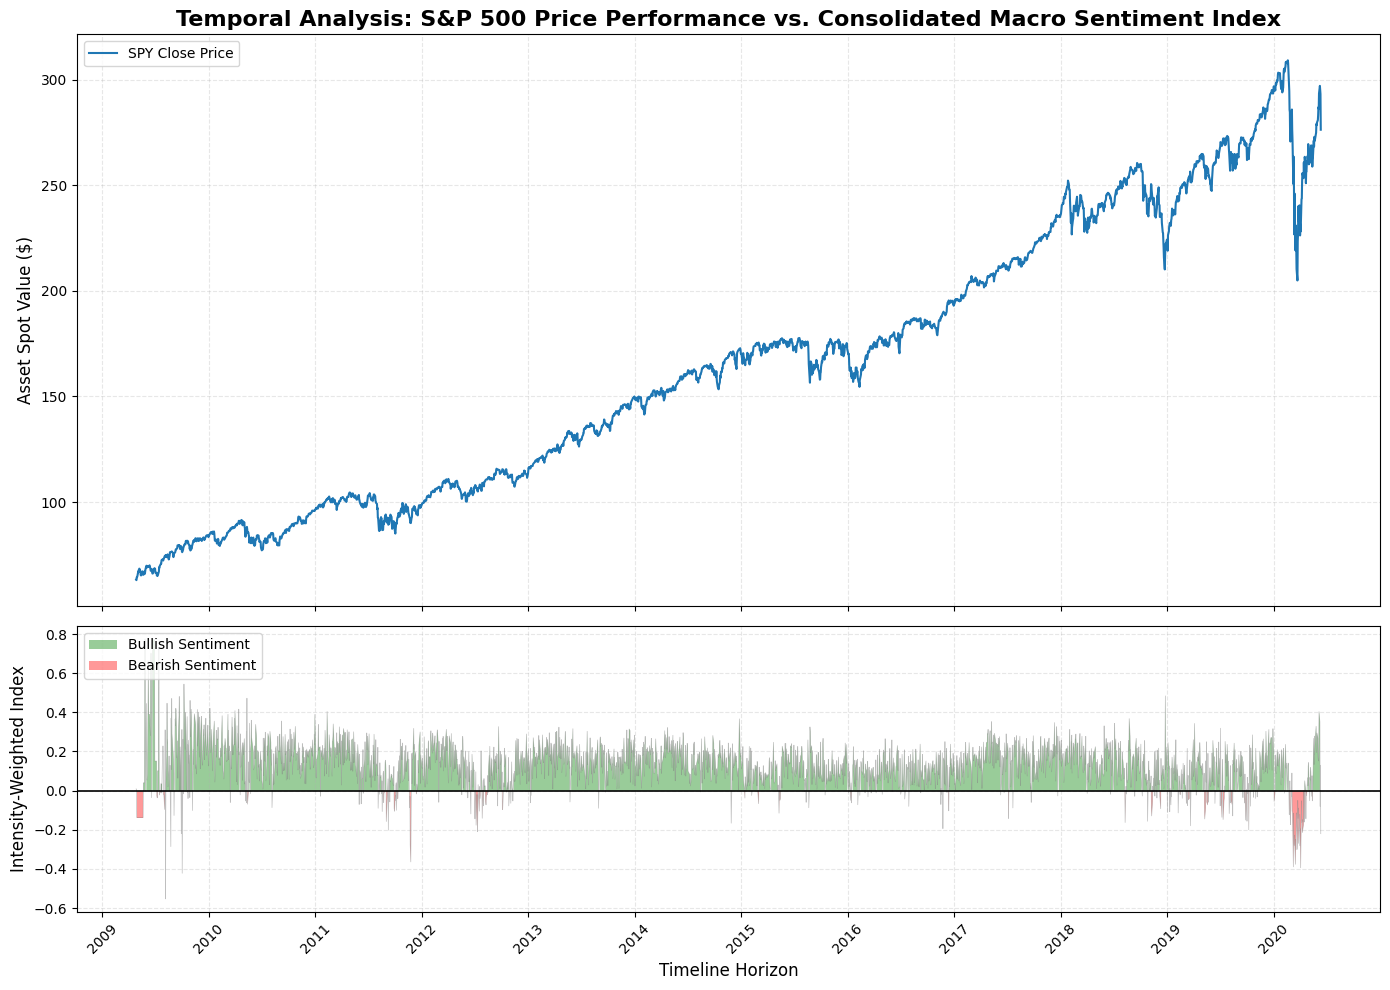

In [10]:
# Export integrated dataset
df_merged.to_csv("../data/quantitative_market_sentiment_dataset.csv", index=False)

# Generate dual-axis market vs. sentiment trajectory plot
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_spy = df_merged[df_merged['ticker'] == 'SPY'].copy()

fig, (ax1, ax2) = plt.subplots(
    nrows=2, 
    ncols=1, \
    figsize=(14, 10), 
    sharex=True, 
    gridspec_kw={'height_ratios': [2, 1]}
)

# Plot market price on top panel
ax1.plot(df_spy['Date'], df_spy['Close'], color='#1f77b4', linewidth=1.5, label='SPY Close Price')
ax1.set_title('Temporal Analysis: S&P 500 Price Performance vs. Consolidated Macro Sentiment Index', fontsize=16, fontweight='bold')
ax1.set_ylabel('Asset Spot Value ($)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, linestyle='--')

# Plot filled sentiment scores on bottom panel
ax2.plot(df_spy['Date'], df_spy['daily_sentiment'], color='gray', linewidth=0.5, alpha=0.5)
ax2.fill_between(df_spy['Date'], 0, df_spy['daily_sentiment'], where=(df_spy['daily_sentiment'] >= 0), facecolor='green', alpha=0.4, label='Bullish Sentiment')
ax2.fill_between(df_spy['Date'], 0, df_spy['daily_sentiment'], where=(df_spy['daily_sentiment'] < 0), facecolor='red', alpha=0.4, label='Bearish Sentiment')
ax2.axhline(0, color='black', linewidth=1.2)
ax2.set_ylabel('Intensity-Weighted Index', fontsize=12)
ax2.set_xlabel('Timeline Horizon', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, linestyle='--')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Multi-Model Volatility Forecasting Pipeline
In this step, we generate predictive inputs for our Reinforcement Learning environment. We load pre-trained machine learning and deep learning (`LSTM`) volatility models and scalers. 

The pipeline extracts a 20-day trailing window for the LSTM layers, formats asset classes into One-Hot Encoded flags, and calculates an ensemble prediction ($\text{mean of ML and DL outputs}$) for the next-day volatility ($\sigma_{t+1}$).

In [11]:
# Cell 21: Reload compiled multi-asset matrix
df_merged = pd.read_csv("../data/quantitative_market_sentiment_dataset.csv")

# Cell 22: Execute sequential time-series feature engineering and inference loop
from tqdm.auto import tqdm
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
from src.inference_volatility import load_artifacts, DEVICE

def generate_empirical_rl_dataset(df, models_dir="../models"):
    print("1. Constructing rolling lag metrics and tracking arrays...")
    df = df.copy().sort_values(['ticker', 'Date']).reset_index(drop=True)
    
    # Generate lag features for structural autoregressive inputs
    df['log_return_lag1'] = df.groupby('ticker')['log_return'].shift(1)
    df['volatility_lag1'] = df.groupby('ticker')['historical_volatility_20d'].shift(1)
    
    # Align asset class profiles with strict Hot-Encoding definitions
    expected_classes = ['Cryptocurrency', 'Equities_Global', 'Equities_US_Broad', 'Fixed_Income', 'Sectors_US']
    for cls in expected_classes:
        df[f'asset_class_{cls}'] = (df['asset_class'] == cls).astype(float)
        
    df = df.dropna().reset_index(drop=True)
    
    print("2. Ingesting pre-trained model instances and statistical scalers...")
    ml_scaler, dl_scaler, ml_models, dl_models = load_artifacts(models_dir)
    
    ohe_cols = [f'asset_class_{cls}' for cls in expected_classes]
    ml_features = ['Volume', 'log_return', 'historical_volatility_20d', 'log_return_lag1', 'volatility_lag1'] + ohe_cols
    dl_features = ['Volume', 'log_return', 'historical_volatility_20d'] + ohe_cols

    df['predicted_volatility_t1'] = np.nan
    tickers = df['ticker'].unique()
    
    print("3. Executing deep-learning sequential inference...")
    for ticker in tqdm(tickers, desc="Processing Tickers"):
        idx_ticker = df[df['ticker'] == ticker].index
        df_t = df.loc[idx_ticker]
        
        if len(df_t) <= 20:
            continue 
            
        for i in range(20, len(df_t)):
            real_idx = idx_ticker[i]
            
            # Extract and scale feature values for Classical ML models
            ml_data = df_t[ml_features].iloc[i:i+1].values
            ml_input_scaled = ml_scaler.transform(ml_data)
            
            # Extract and scale a 20-day historical tensor slice for deep learning LSTM models
            dl_data = df_t[dl_features].iloc[i-20:i].values
            dl_data_scaled = dl_scaler.transform(dl_data)
            dl_input_tensor = torch.tensor(dl_data_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            
            # Run model evaluations
            preds = []
            for model in ml_models.values():
                preds.append(float(model.predict(ml_input_scaled)[0]))\
                
            with torch.no_grad():
                for model in dl_models.values():
                    preds.append(model(dl_input_tensor).item())
                    
            # Compute final predictive consensus (ensemble mean value)
            df.loc[real_idx, 'predicted_volatility_t1'] = np.mean(preds)
            
    # Purge initialization records that lack historical trailing features
    df_final = df.dropna(subset=['predicted_volatility_t1']).reset_index(drop=True)
    return df_final.drop(columns=['log_return_lag1', 'volatility_lag1'] + ohe_cols)

# Run the inference engine and save the results
df_empirico = generate_empirical_rl_dataset(df_merged, models_dir="../models")
df_empirico.to_csv("../data/dataset_empirico_rl.csv", index=False)
print("Empirical dataset generated successfully for Reinforcement Learning.")

1. Constructing rolling lag metrics and tracking arrays...
2. Ingesting pre-trained model instances and statistical scalers...
3. Executing deep-learning sequential inference...


Processing Tickers: 100%|██████████| 20/20 [33:20<00:00, 100.03s/it]


Empirical dataset generated successfully for Reinforcement Learning.


## 12. In-Sample Training & Out-of-Sample Backtesting Partitions with Anti-Leakage Z-Score
To prevent **look-ahead bias** and data leakage into the Reinforcement Learning agent, the dataset is split sequentially: **In-Sample Train** (May 2009 – December 2018) and **Out-of-Sample Backtest** (January 2019 – June 2020). 

Crucially, the sentiment Z-score normalization parameters ($\mu$ and $\sigma$) are computed **solely using training data** and then applied downstream to both sets. We also clip values to $[-3.0, 3.0]$ to prevent gradient explosion in Proximal Policy Optimization (PPO).

In [12]:
os.makedirs("../data", exist_ok=True)
df_merged = pd.read_csv("../data/dataset_empirico_rl.csv")
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged = df_merged.sort_values(['Date', 'ticker']).reset_index(drop=True)

# Define out-of-sample timeline cutoff parameter
CUTOFF_DATE = '2019-01-01'

# Calculate normalization factors strictly using in-sample data limits
df_train_fit = df_merged[df_merged['Date'] < CUTOFF_DATE]
VALOR_MU_SENTIMENT = float(df_train_fit['daily_sentiment'].mean())
VALOR_SIGMA_SENTIMENT = float(df_train_fit['daily_sentiment'].std())

# Standardize entire dataset using training partition attributes (Anti-leakage)
df_merged['sentiment_zscore'] = (df_merged['daily_sentiment'] - VALOR_MU_SENTIMENT) / VALOR_SIGMA_SENTIMENT
df_merged['sentiment_zscore'] = df_merged['sentiment_zscore'].fillna(0.0).replace([np.inf, -np.inf], 0.0)

# Clamp data bounds to safeguard policy models against gradient explosion
df_merged['sentiment_zscore'] = np.clip(df_merged['sentiment_zscore'], -3.0, 3.0)

# Isolate datasets into separate files
df_train = df_merged[df_merged['Date'] < CUTOFF_DATE].copy().reset_index(drop=True)
df_backtest = df_merged[df_merged['Date'] >= CUTOFF_DATE].copy().reset_index(drop=True)

df_train.to_csv("../data/train_agent_dataset.csv", index=False)
df_backtest.to_csv("../data/backtest_agent_dataset.csv", index=False)

# Print execution audit report
total_tickers = df_merged['ticker'].nunique()
print("=" * 70)
print(f"Calculated In-Sample Training Normalization Statistics:")
print(f"  · Sentiment Mean (µ):               {VALOR_MU_SENTIMENT:.6f}")
print(f"  · Sentiment Deviation (σ):          {VALOR_SIGMA_SENTIMENT:.6f}")
print(f"  · PPO Boundary Guard Rail:          Clamped strictly within [-3.0, 3.0]")
print("-" * 70)
print(f"📈 IN-SAMPLE TRAINING DATASET (dataset_train.csv):")
print(f"  · Range Start:                      {df_train['Date'].min().date()}")
print(f"  · Range End:                        {df_train['Date'].max().date()}")
print(f"  · Matrix Dimensions:                {len(df_train):,} rows x {df_train['Date'].nunique():,} steps")
print("-" * 70)
print(f"📊 OUT-OF-SAMPLE EVALUACIÓN / BACKTEST (dataset_backtest.csv):")
print(f"  · Range Start:                      {df_backtest['Date'].min().date()}")
print(f"  · Range End:                        {df_backtest['Date'].max().date()}")
print(f"  · Matrix Dimensions:                {len(df_backtest):,} rows x {df_backtest['Date'].nunique():,} steps")
print("=" * 70)

Calculated In-Sample Training Normalization Statistics:
  · Sentiment Mean (µ):               0.143970
  · Sentiment Deviation (σ):          0.114915
  · PPO Boundary Guard Rail:          Clamped strictly within [-3.0, 3.0]
----------------------------------------------------------------------
📈 IN-SAMPLE TRAINING DATASET (dataset_train.csv):
  · Range Start:                      2009-05-27
  · Range End:                        2018-12-31
  · Matrix Dimensions:                42,664 rows x 2,892 steps
----------------------------------------------------------------------
📊 OUT-OF-SAMPLE EVALUACIÓN / BACKTEST (dataset_backtest.csv):
  · Range Start:                      2019-01-01
  · Range End:                        2020-06-11
  · Matrix Dimensions:                7,772 rows x 528 steps
